# Norman 2019 — GRN Calculation

Infers a Gene Regulatory Network (GRN) from the preprocessed control cells using CellOracle.

> **Environment:** this notebook must be run inside the CellOracle Docker container.

**Pipeline overview**

| Step | Description |
|------|-------------|
| 0 | Load data; restrict to control cells; prepare for CellOracle (raw counts, PCA) |
| 1 | Initialise Oracle object; load base GRN (TF-motif database) |
| 2 | KNN imputation of gene expression |
| 3 | Infer GRN via regularised regression |
| 4 | Save raw GRN; inspect network topology |

**Input files** (place under `data/real/Norman2019/`)
- `Norman2019_raw.h5ad` — preprocessed single-cell data (see `data/real/Norman2019/README.md`)
- `GRN/hg38_TFinfo_dataframe_gimmemotifsv5_fpr2_threshold_10_20210630.parquet` — base GRN

**Output files**
- `GRN/raw_GRN.csv` — inferred edges (TF → target, with coefficients)
- `GRN/links.celloracle.links` — full CellOracle Links object

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import celloracle as co

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams['savefig.dpi'] = 300

co.__version__

In [ ]:
data_folder = '../../../data/real/Norman2019/'

## 0. Load data and restrict to control cells

In [ ]:
adata = sc.read_h5ad(data_folder + 'Norman2019_raw.h5ad')
adata

In [ ]:
# CellOracle requires raw counts and X_pca already present in obsm.
# GRN inference runs on control cells only to capture baseline regulatory structure.
# var_names must be set to gene symbols (raw data uses Ensembl IDs as index).
adata = adata[adata.obs['condition'] == 'ctrl', :]
adata.var_names = adata.var['gene_symbols']
adata.layers['normalized'] = adata.X.copy()
adata.X = adata.layers['counts'].copy()
sc.tl.pca(adata)
print(f'Cells: {adata.n_obs:,}  |  Genes: {adata.n_vars:,}')

## 1. Initialise Oracle object and load base GRN

In [ ]:
base_GRN = pd.read_parquet(
    data_folder + 'GRN/hg38_TFinfo_dataframe_gimmemotifsv5_fpr2_threshold_10_20210630.parquet'
)
base_GRN.head()

In [ ]:
oracle = co.Oracle()

oracle.import_anndata_as_raw_count(
    adata=adata,
    cluster_column_name='cell_type',
    embedding_name='X_pca',
)
oracle.import_TF_data(TF_info_matrix=base_GRN)

## 2. KNN imputation

In [ ]:
oracle.perform_PCA()

plt.plot(np.cumsum(oracle.pca.explained_variance_ratio_)[:100])
n_comps = np.where(np.diff(np.diff(np.cumsum(oracle.pca.explained_variance_ratio_)) > 0.002))[0][0]
plt.axvline(n_comps, c='k')
plt.xlabel('PC')
plt.ylabel('Cumulative explained variance')
plt.title('Elbow plot — number of PCs for KNN')
plt.tight_layout()
plt.show()
print(f'Selected n_comps: {n_comps}')

# Cap at 50 to match the PCA dimensionality used in notebook 0.
n_comps = min(n_comps, 50)

In [ ]:
n_cell = oracle.adata.shape[0]
k = int(0.025 * n_cell)
print(f'Cells: {n_cell}  |  k (2.5% of cells): {k}')

oracle.knn_imputation(n_pca_dims=n_comps, k=k, balanced=True, b_sight=k*8, b_maxl=k*4, n_jobs=4)
print(oracle)

## 3. GRN inference

In [ ]:
sc.pp.neighbors(oracle.adata)
sc.tl.draw_graph(oracle.adata)
sc.pl.draw_graph(oracle.adata, color='cell_type')

In [ ]:
%%time
# Regularised regression per target gene, per cluster. Runtime ~7 minutes.
links = oracle.get_links(cluster_name_for_GRN_unit='cell_type', alpha=10, verbose_level=10)

## 4. Save and inspect network topology

In [ ]:
import os
os.makedirs(data_folder + 'GRN', exist_ok=True)

links.links_dict['K562'].to_csv(data_folder + 'GRN/raw_GRN.csv')
links.to_hdf5(file_path=data_folder + 'GRN/links.celloracle.links')
print(f'Saved → {data_folder}GRN/raw_GRN.csv')
print(f'Saved → {data_folder}GRN/links.celloracle.links')

### Degree distribution (filtered network)

In [ ]:
# Filter to top edges for visualisation; does not affect the saved raw_GRN.csv.
links.filter_links(p=0.001, weight='coef_abs', threshold_number=2000)

plt.rcParams['figure.figsize'] = [9, 4.5]
links.plot_degree_distributions(plot_model=True)

### Degree distribution (raw network, log-log)

In [ ]:
raw_grn_df = links.links_dict['K562']

in_deg    = raw_grn_df['target'].value_counts()
deg_freq  = in_deg.value_counts().sort_index()
probability = deg_freq / deg_freq.sum()

log_k = np.log10(deg_freq.index)
log_p = np.log10(probability)
slope, intercept = np.polyfit(log_k, log_p, 1)
r2 = np.corrcoef(log_k, log_p)[0, 1] ** 2

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].scatter(deg_freq.index, probability, color='black')
axes[0].set_xlabel('k')
axes[0].set_ylabel('P(k)')
axes[0].set_title('In-degree distribution')

axes[1].scatter(log_k, log_p, color='black')
axes[1].plot(log_k, slope * log_k + intercept, color='gray')
axes[1].set_xlabel('log k')
axes[1].set_ylabel('log P(k)')
axes[1].set_title(f'Log-log in-degree\nslope={slope:.3f}, R²={r2:.3f}')

plt.tight_layout()
plt.show()

### Network centrality scores

In [ ]:
links.get_network_score()
links.merged_score.head()

### Top genes by centrality

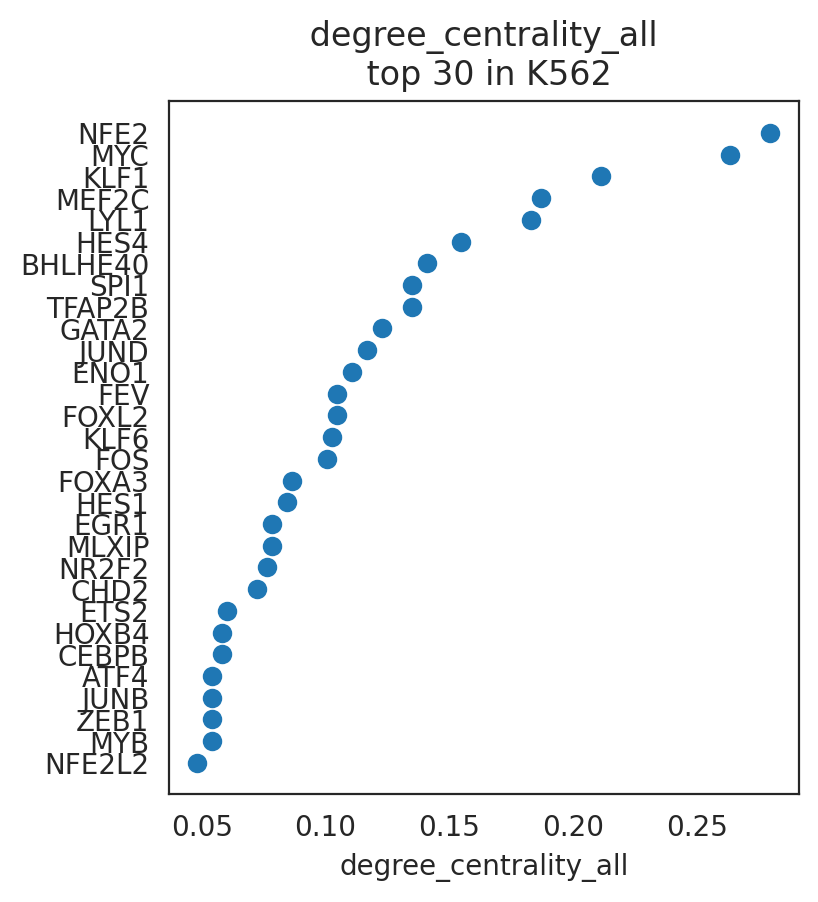

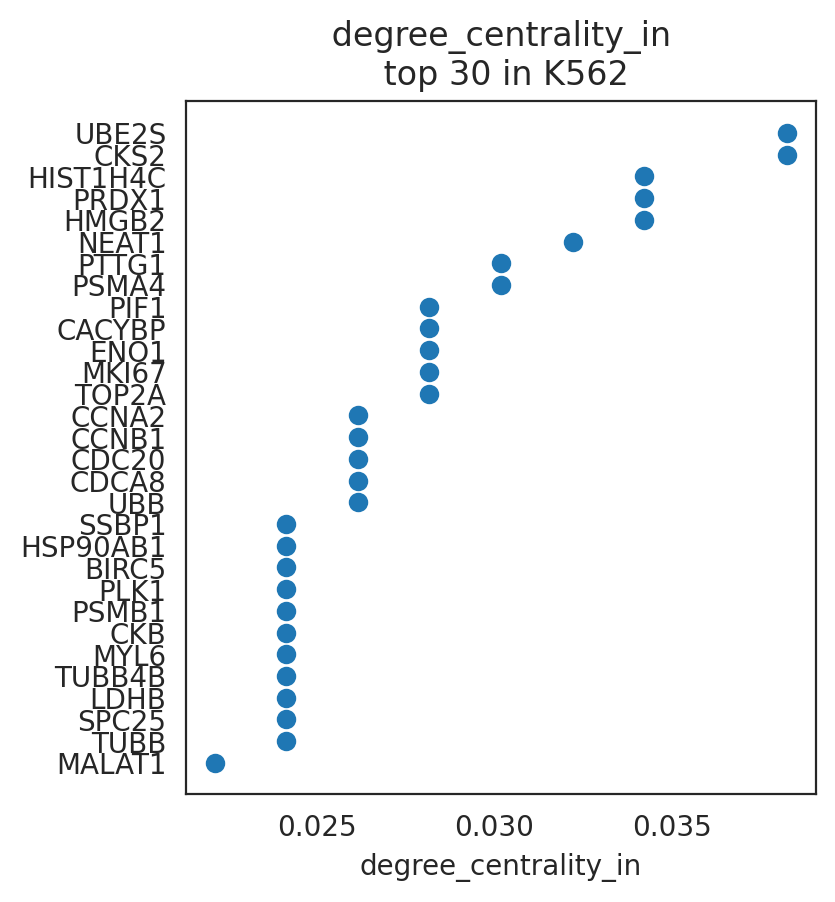

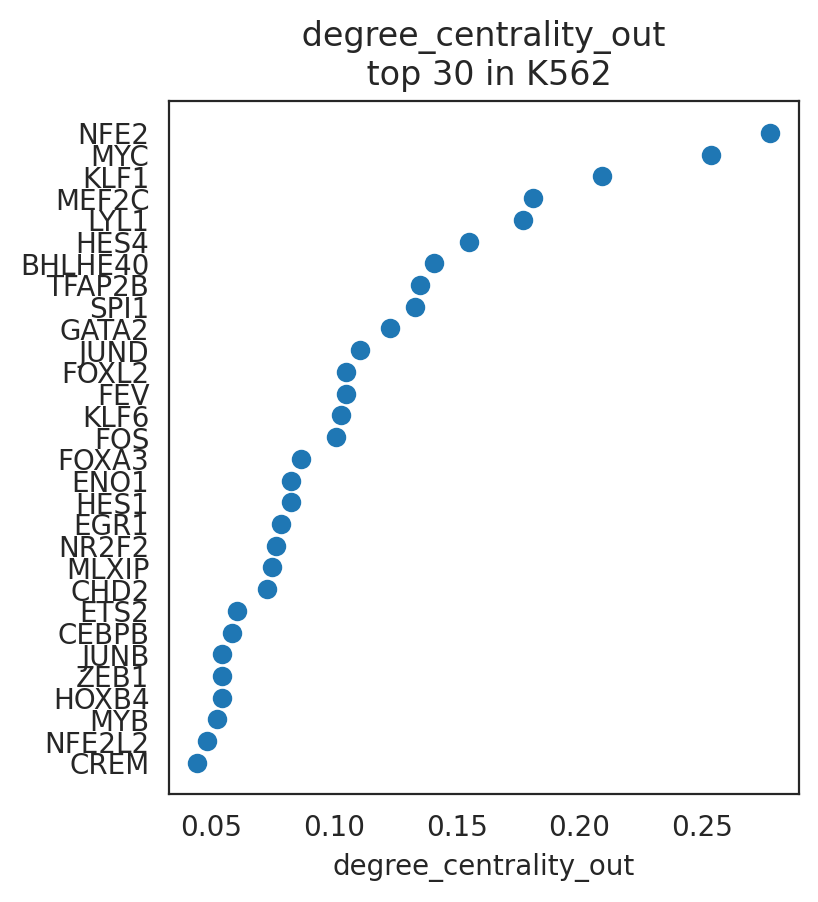

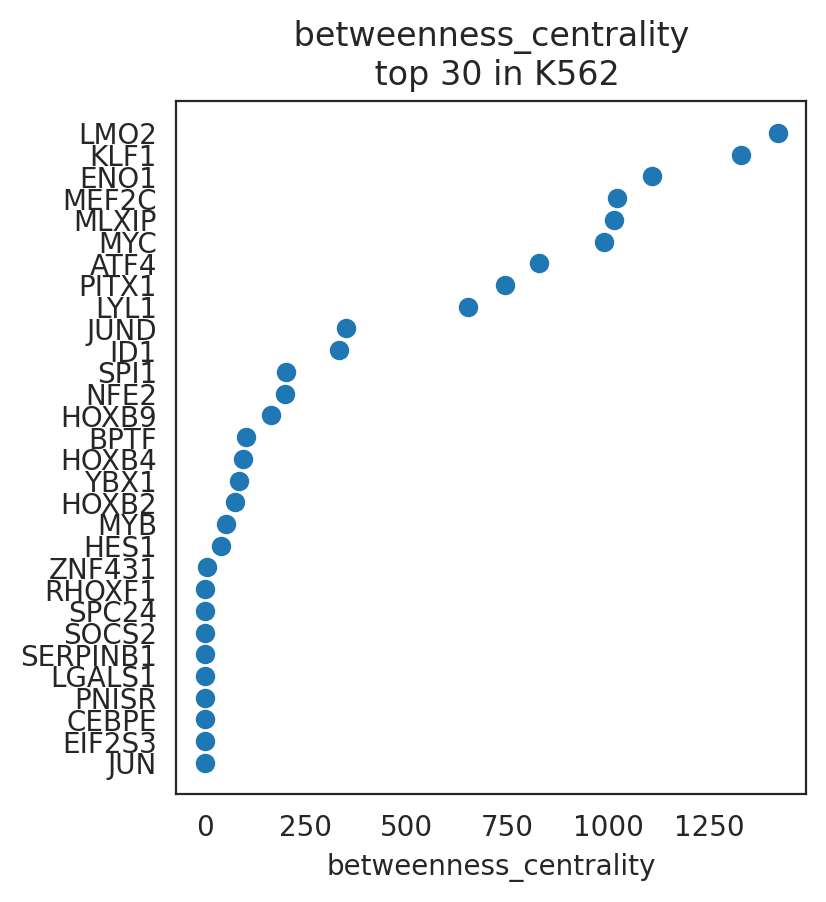

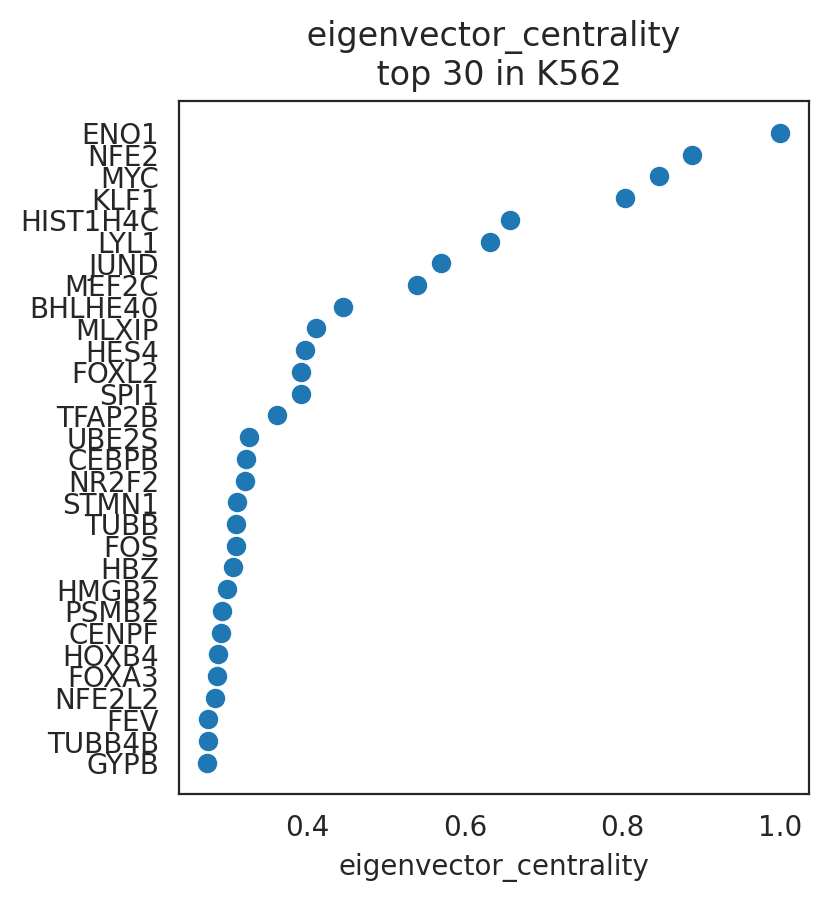

In [54]:
links.plot_scores_as_rank(cluster="K562", n_gene=30)